<h2> Discrétisation du OU DSM : le modèle DDPM</h2>

Imports

In [2]:
import torch
import torchvision
from matplotlib import pyplot as plt
from sympy.abc import sigma
from tqdm.notebook import tqdm
from torch import nn, optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np

Chargement des données

In [3]:
TRANSFORMS = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

ds = torchvision.datasets.MNIST("/tmp/mnist", train=True, transform=TRANSFORMS, target_transform=None, download=True)

batch_size = 128
input_size = 784

dataloader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)


Construction de réseau de neurone

In [4]:
# version 1 : réseau au feeling

net = nn.Sequential(nn.Linear(input_size+1, 512),
                    nn.ReLU(),
                    nn.Linear(512, 128),
                    nn.ReLU(),
                    nn.Linear(128, 1),)

optimizer = optim.Adam(net.parameters(), lr=0.001)


In [9]:
# version 2 : UNET basique

class BasicUNet(nn.Module):
    """A minimal UNet implementation."""

    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(in_channels, out_channels=32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
            ]
        )
        self.up_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
            ]
        )
        self.act = nn.SiLU()  # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x))  # Through the layer and the activation function
            if i < 2:  # For all but the third (final) down layer:
                h.append(x)  # Storing output for skip connection
                x = self.downscale(x)  # Downscale ready for the next layer

        for i, l in enumerate(self.up_layers):
            if i > 0:  # For all except the first up layer
                x = self.upscale(x)  # Upscale
                x += h.pop()  # Fetching stored output (skip connection)
            x = self.act(l(x))  # Through the layer and the activation function

        return x

In [10]:
unet = BasicUNet()
x = next(iter(dataloader))

unet(x).shape

TypeError: conv2d() received an invalid combination of arguments - got (list, Parameter, Parameter, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!list of [Tensor, Tensor]!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!list of [Tensor, Tensor]!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)


Générateur

In [92]:
T = 1000
beta = torch.linspace(10*1e-4, 0.02, steps=T) # choix inspiré par Ho et al.
alpha = torch.cumprod(1-beta, dim=0)
e_dist = torch.distributions.normal.Normal(0, 1)


def generate(nb_samples=1):
    for _ in range(nb_samples):
        X = e_dist.sample([input_size])
        for t in reversed(range(T)):
            t = torch.as_tensor([t])
            Zt = e_dist.sample([input_size])
            in_tensor_ = torch.cat((X, t), dim=0)
            X = 1/((1-beta[t]).sqrt()) * (X - (beta[t]/((1-alpha[t]).sqrt()))*net(in_tensor_)) + beta[t]*Zt

        img = X.detach().numpy().reshape(28,28)
        plt.figure(figsize=(2,2))
        plt.imshow(img, cmap='gray')
        plt.show()

    plt.show()



Entraînement

Epoch 0/50:   0%|          | 0/468 [00:00<?, ?it/s]

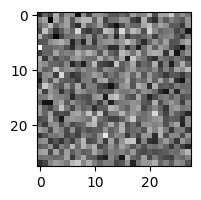

Epoch 1/50:   0%|          | 0/468 [00:00<?, ?it/s]

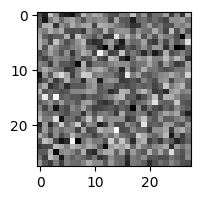

Epoch 2/50:   0%|          | 0/468 [00:00<?, ?it/s]

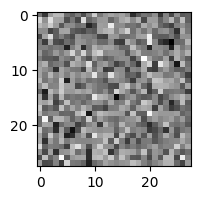

Epoch 3/50:   0%|          | 0/468 [00:00<?, ?it/s]

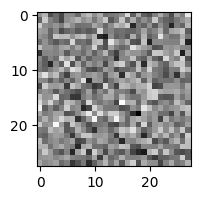

Epoch 4/50:   0%|          | 0/468 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [93]:
nb_epochs = 50
criterion = nn.MSELoss()

for epoch in range(nb_epochs):
    for X0, _ in tqdm(dataloader, desc=f"Epoch {epoch}/{nb_epochs}"):

        X0 = torch.flatten(X0.squeeze(), 1, 2) # -> [batchsize, 784]
        e = e_dist.sample([batch_size, input_size])
        t = torch.randint(1, T, size=[batch_size, 1])

        Xt = alpha[t].sqrt() * X0 + (1-alpha[t]).sqrt() * e
        in_tensor = torch.concat([Xt, t], dim=1)

        e_theta = net(in_tensor)
        loss = criterion(e, e_theta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    generate()


